# RetailEL — Retail Entity Linking Pipeline
**FAST NUCES Islamabad | Spring 2026 | NLP Project**

### Pipeline Stages
1. Text Normalisation (abbreviation expansion)
2. Basket Context Construction (RoCEL-inspired)
3. Hybrid BM25 + TF-IDF Retrieval with RRF
4. LightGBM LambdaRank Reranking
5. Constrained FSM Selection

### Run Order
Run every cell top-to-bottom. Upload your Instacart CSV files when prompted in **Section 2**.

## Section 1 — Setup & GPU Check

In [1]:
# Install required packages
!pip install -q rank_bm25 python-Levenshtein lightgbm sentence-transformers tqdm pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.8 MB/s eta 0:00:00


In [2]:
import torch
import os, json, csv, re, random, time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional

random.seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found — running on CPU (still works fine)")

os.makedirs("data",      exist_ok=True)
os.makedirs("data_real", exist_ok=True)
os.makedirs("results",   exist_ok=True)
print("Directories ready.")

Device : cuda
GPU    : Tesla T4
Directories ready.


## Section 2 — Upload Instacart CSV Files

In [3]:
# Upload the 4 Instacart CSV files from your local machine.
# Required files:
#   products.csv            (product_id, product_name, aisle_id, department_id)
#   departments.csv         (department_id, department)
#   orders.csv              (order_id, user_id, ...)
#   order_products__train.csv (order_id, product_id, ...)

from google.colab import files

print("Select all 4 CSV files at once (Ctrl+Click to multi-select):")
uploaded = files.upload()

REQUIRED = ["products.csv", "departments.csv", "orders.csv", "order_products__train.csv"]
missing  = [f for f in REQUIRED if not Path(f).exists()]

if missing:
    print(f"\nMISSING: {missing}")
    print("Falling back to arules groceries (155 SKUs) — pipeline still works.")
    USE_LOCAL_INSTACART = False
else:
    print("\nAll 4 files uploaded.")
    USE_LOCAL_INSTACART = True

print(f"USE_LOCAL_INSTACART = {USE_LOCAL_INSTACART}")

Select all 4 CSV files at once (Ctrl+Click to multi-select):


Saving departments.csv to departments (1).csv
Saving order_products__train.csv to order_products__train (1).csv
Saving orders.csv to orders (1).csv
Saving products.csv to products (1).csv

All 4 files uploaded.
USE_LOCAL_INSTACART = True


## Section 3 — Noise Engine (Shared)

In [4]:
# Abbreviation table — brand + descriptor + unit abbreviations
ABBREVS = {
    "Organic":"Org", "Chocolate":"Choc", "Chicken":"Chkn",
    "Cheese":"Chs", "Bottle":"Btl", "Pack":"Pk",
    "Greek":"Grk", "Yogurt":"Ygt", "Strawberry":"Strbry",
    "Vanilla":"Vnl", "Ketchup":"Ktchp", "Mustard":"Mstd",
    "Tomato":"Tmt", "Peanut":"Pnt", "Butter":"Btr",
    "Shampoo":"Shmp", "Conditioner":"Cond", "Toothpaste":"Tpst",
    "Original":"Orig", "Natural":"Natrl", "Classic":"Clsc",
}

def apply_abbreviation(text):
    for full, short in ABBREVS.items():
        text = re.sub(full, short, text, flags=re.IGNORECASE)
    return text

def keyboard_typo(word):
    if len(word) < 3: return word
    idx = random.randint(0, len(word)-1)
    return word[:idx] + random.choice("abcdefghijklmnopqrstuvwxyz") + word[idx+1:]

def drop_vowels(word):
    if len(word) <= 3: return word
    return word[0] + ''.join(c for c in word[1:] if c.lower() not in "aeiou")

def add_noise(name, noise_level=0.4):
    """General noise for robustness testing."""
    text  = apply_abbreviation(str(name))
    words = text.split()
    noisy = []
    for w in words:
        r = random.random()
        if len(w) > 3 and r < noise_level * 0.35:
            w = keyboard_typo(w)
        elif len(w) > 3 and r < noise_level * 0.60:
            w = drop_vowels(w)
        elif r < noise_level * 0.85:
            w = w.upper() if random.random() < 0.5 else w.lower()
        noisy.append(w)
    if len(noisy) > 3 and random.random() < 0.20:
        noisy.pop(random.randint(0, len(noisy)-1))
    return " ".join(noisy)

def pos_truncate(name, char_limit):
    """Simulate POS character-limit truncation."""
    if len(name) <= char_limit: return name
    t = name[:char_limit]
    sp = t.rfind(" ")
    return t[:sp].rstrip() if sp > char_limit * 0.55 else t.rstrip()

def make_pos_noise(name, style):
    """style: 'legacy'(30) | 'standard'(40) | 'modern'(50)"""
    limits = {"legacy":30, "standard":40, "modern":50}
    text   = apply_abbreviation(name)
    if style == "legacy":
        text = text.upper()
        ws   = text.split()
        if len(ws) > 2 and random.random() < 0.35:
            i = random.randint(0, len(ws)-2)
            ws[i] = ws[i]+ws[i+1]; ws.pop(i+1)
        text = " ".join(ws)
    elif style == "standard":
        ws   = text.split()
        text = " ".join(keyboard_typo(w) if random.random()<0.12 else w for w in ws)
    return pos_truncate(text, limits.get(style, 40)).strip()

print("Noise engine ready.")
print(f"  Sample legacy : {make_pos_noise('Heinz Tomato Ketchup 32oz Bottle', 'legacy')}")
print(f"  Sample standard: {make_pos_noise('Heinz Tomato Ketchup 32oz Bottle', 'standard')}")
print(f"  Sample modern : {make_pos_noise('Heinz Tomato Ketchup 32oz Bottle', 'modern')}")

Noise engine ready.
  Sample legacy : HEINZ TMT KTCHP 32OZ BTL
  Sample standard: Hehnz Tmt Ktchp 32oz Btl
  Sample modern : Heinz Tmt Ktchp 32oz Btl


## Section 4 — Dataset Generation

In [5]:
# ── Generate data/catalogue.json + data/synel_dataset.csv ──────────────────
# Uses local Instacart files if uploaded; otherwise uses arules fallback.

DEPT_CATEGORY = {
    "frozen":"Frozen","bakery":"Bakery","produce":"Produce",
    "beverages":"Beverages","dry goods pasta":"Pantry","pantry":"Pantry",
    "canned goods":"Canned","breakfast":"Breakfast","dairy eggs":"Dairy",
    "household":"Household","snacks":"Snacks","deli":"Deli",
    "personal care":"Personal","meat seafood":"Meat",
}
KEEP_DEPTS = set(DEPT_CATEGORY.keys())

KNOWN_DEPTS = {
    "1":"frozen","3":"bakery","4":"produce","7":"beverages",
    "9":"dry goods pasta","13":"pantry","14":"breakfast",
    "15":"canned goods","16":"dairy eggs","17":"household",
    "19":"snacks","20":"deli","11":"personal care","12":"meat seafood",
}

def build_catalogue_instacart(products_csv, depts_csv, max_skus=500):
    depts = pd.read_csv(depts_csv)
    prods = pd.read_csv(products_csv)
    dept_map = {str(r["department_id"]):r["department"].lower() for _,r in depts.iterrows()}
    cat, seen = [], set()
    for _, row in prods.iterrows():
        name = str(row["product_name"]).strip()
        if not name or name.lower() in seen: continue
        d = dept_map.get(str(row.get("department_id","")),"other").lower()
        if d not in KEEP_DEPTS: continue
        seen.add(name.lower())
        brand = name.split()[0].title() if name.split()[0][0].isupper() else "Generic"
        cat.append({"sku":f"GRC-{len(cat)+1:04d}","name":name,
                    "brand":brand,"category":DEPT_CATEGORY.get(d,"General")})
        if len(cat) >= max_skus: break
    return cat

def build_catalogue_arules(max_skus=500):
    """Fallback: hardcoded expansion of arules 169 category tokens."""
    items = [
        ("Horizon Organic Whole Milk 1gal","Horizon","Dairy"),
        ("Lucerne Whole Milk 1gal","Lucerne","Dairy"),
        ("Coca-Cola Classic 12pk 12oz","CocaCola","Beverages"),
        ("Pepsi Regular 12pk 12oz","Pepsi","Beverages"),
        ("Sprite 12pk 12oz Cans","Sprite","Beverages"),
        ("Chobani Greek Yogurt Plain 32oz","Chobani","Dairy"),
        ("Yoplait Strawberry Yogurt 6oz","Yoplait","Dairy"),
        ("Nestle Pure Life Water 24pk","Nestle","Beverages"),
        ("Dasani Purified Water 20oz","Dasani","Beverages"),
        ("Tropicana OJ No Pulp 52oz","Tropicana","Beverages"),
        ("Ocean Spray Cranberry Juice 64oz","OceanSpray","Beverages"),
        ("Heinz Tomato Ketchup 32oz Bottle","Heinz","Condiments"),
        ("Hunt's Ketchup 24oz Bottle","Hunts","Condiments"),
        ("French's Yellow Mustard 20oz","Frenchs","Condiments"),
        ("Hellmann's Real Mayonnaise 30oz","Hellmanns","Condiments"),
        ("Campbell's Tomato Soup 10.75oz","Campbells","Canned"),
        ("Progresso Chicken Noodle 18.5oz","Progresso","Canned"),
        ("Del Monte Sweet Corn 15.25oz","DelMonte","Canned"),
        ("Barilla Spaghetti 16oz","Barilla","Pantry"),
        ("Uncle Ben's Long Grain White Rice 5lb","UncleBens","Pantry"),
        ("Kellogg's Corn Flakes 18oz","Kelloggs","Breakfast"),
        ("Cheerios Original 18oz","GeneralMills","Breakfast"),
        ("Quaker Old Fashioned Oats 42oz","Quaker","Breakfast"),
        ("Skippy Peanut Butter Creamy 16.3oz","Skippy","Spreads"),
        ("Jif Peanut Butter Creamy 16oz","Jif","Spreads"),
        ("Smucker's Strawberry Jam 18oz","Smuckers","Spreads"),
        ("Wonder Bread Classic White 20oz","Wonder","Bakery"),
        ("Dave's Killer Bread 21 Grain","Daves","Bakery"),
        ("Eggo Homestyle Waffles 10ct","Eggo","Frozen"),
        ("Birds Eye Broccoli Florets 12oz","BirdsEye","Frozen"),
        ("DiGiorno Rising Crust Pizza 28.2oz","DiGiorno","Frozen"),
        ("Ben & Jerry's Chocolate Fudge Brownie","BenJerrys","Frozen"),
        ("Haagen-Dazs Vanilla Ice Cream 14oz","HaagenDazs","Frozen"),
        ("Tide Pods Laundry 42ct","Tide","Household"),
        ("Bounty Select-A-Size Paper Towels 12pk","Bounty","Household"),
        ("Charmin Ultra Soft 12 Rolls","Charmin","Household"),
        ("Lysol Disinfectant Spray 19oz","Lysol","Household"),
        ("Dawn Dish Soap Original 19.4oz","Dawn","Household"),
        ("Colgate Toothpaste Total 4.8oz","Colgate","Personal"),
        ("Head & Shoulders Shampoo 13.5oz","HS","Personal"),
        ("Dove Bar Soap 6pk 3.75oz","Dove","Personal"),
        ("Lay's Classic Chips 8oz Bag","Lays","Snacks"),
        ("Doritos Nacho Cheese 9.75oz","Doritos","Snacks"),
        ("Pringles Original 5.96oz Can","Pringles","Snacks"),
        ("Oreo Cookies 14.3oz Pack","Oreo","Snacks"),
        ("Red Bull Energy 8.4oz Can","RedBull","Beverages"),
        ("Monster Energy Original 16oz","Monster","Beverages"),
        ("Gatorade Lemon Lime 32oz","Gatorade","Beverages"),
        ("Tyson Chicken Breasts 3lb","Tyson","Meat"),
        ("Oscar Mayer Bacon 16oz","OscarMayer","Meat"),
    ]
    return [{"sku":f"GRC-{i+1:04d}","name":n,"brand":b,"category":c}
            for i,(n,b,c) in enumerate(items[:max_skus])]

# Build catalogue
if USE_LOCAL_INSTACART:
    catalogue = build_catalogue_instacart("products.csv","departments.csv",500)
else:
    catalogue = build_catalogue_arules(50)

print(f"Catalogue: {len(catalogue)} SKUs")

# Save catalogue
with open("data/catalogue.json","w") as f:
    json.dump(catalogue, f, indent=2)
print(f"Saved -> data/catalogue.json")

Catalogue: 500 SKUs
Saved -> data/catalogue.json


In [6]:
# ── Generate synthetic POS transactions ──────────────────────────────────────

def make_basket(catalogue, size=5):
    items = random.sample(catalogue, min(size, len(catalogue)))
    return [{
        "description":   make_pos_noise(e["name"], random.choice(["legacy","standard","modern"])),
        "canonical_name":e["name"],
        "sku":           e["sku"],
        "quantity":      random.randint(1,4),
        "price":         round(random.uniform(0.99,14.99),2),
        "department":    e["category"],
    } for e in items]

N_TRANSACTIONS = 500
transactions, all_items = [], []
for txn_id in range(1000, 1000 + N_TRANSACTIONS):
    basket = make_basket(catalogue, random.randint(3,8))
    for item in basket:
        item["transaction_id"] = f"TXN-{txn_id}"
    transactions.append({"transaction_id":f"TXN-{txn_id}","items":basket})
    all_items.extend(basket)

fieldnames = ["transaction_id","description","canonical_name","sku","quantity","price","department"]
with open("data/synel_dataset.csv","w",newline="",encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader(); w.writerows(all_items)

with open("data/transactions.json","w") as f:
    json.dump(transactions, f, indent=2)

print(f"Generated {len(transactions)} transactions, {len(all_items)} items")
print("Saved -> data/synel_dataset.csv, data/transactions.json")

Generated 500 transactions, 2814 items
Saved -> data/synel_dataset.csv, data/transactions.json


## Section 5 — Real Dataset (data_real/)

In [7]:
# Builds data_real/ from the same Instacart catalogue with POS-noise variants

N_REAL_TRANSACTIONS = 2000
real_catalogue = catalogue  # same products, different noise style

with open("data_real/catalogue_real.json","w") as f:
    json.dump(real_catalogue, f, indent=2)

real_pairs, real_transactions = [], []
for txn_id in range(5000, 5000 + N_REAL_TRANSACTIONS):
    size   = random.randint(3, 8)
    chosen = random.sample(real_catalogue, min(size, len(real_catalogue)))
    basket = []
    for e in chosen:
        style = random.choice(["legacy","standard","modern"])
        noisy = make_pos_noise(e["name"], style)
        item  = {
            "transaction_id": f"TXN-{txn_id}",
            "description":    noisy,
            "canonical_name": e["name"],
            "sku":            e["sku"],
            "quantity":       random.randint(1,4),
            "price":          round(random.uniform(0.99,14.99),2),
            "department":     e["category"],
            "pos_style":      style,
            "is_variant":     noisy.lower() != e["name"].lower(),
        }
        basket.append(item)
    real_transactions.append({"transaction_id":f"TXN-{txn_id}","items":basket})
    real_pairs.extend(basket)

fields = ["transaction_id","description","canonical_name","sku",
          "quantity","price","department","pos_style","is_variant"]
with open("data_real/synel_real.csv","w",newline="",encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fields)
    w.writeheader(); w.writerows(real_pairs)

with open("data_real/transactions_real.json","w") as f:
    json.dump(real_transactions[:5000], f, indent=2)

variant_ct = sum(1 for p in real_pairs if p["is_variant"])
print(f"Real dataset: {len(real_catalogue)} SKUs | {len(real_pairs)} pairs")
print(f"Noisy variants: {variant_ct}/{len(real_pairs)} ({variant_ct/len(real_pairs)*100:.1f}%)")
print("Saved -> data_real/catalogue_real.json, data_real/synel_real.csv")

Real dataset: 500 SKUs | 11015 pairs
Noisy variants: 6559/11015 (59.5%)
Saved -> data_real/catalogue_real.json, data_real/synel_real.csv


## Section 6 — Pipeline Definition (All 5 Stages)

In [8]:
# ── Stage 1: Data Structures & Normalisation ──────────────────────────────────
import Levenshtein
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
import lightgbm as lgb
from tqdm import tqdm

@dataclass
class Item:
    description:    str
    sku:            str
    quantity:       int   = 1
    price:          float = 0.0
    department:     str   = ""
    transaction_id: str   = ""
    basket_context: str   = ""
    predicted_sku:  str   = ""
    confidence:     float = 0.0
    stage_times:    dict  = field(default_factory=dict)

@dataclass
class SKUEntry:
    sku:      str
    name:     str
    brand:    str
    category: str
    def search_text(self) -> str:
        return f"{self.name} {self.brand} {self.category}"

ABBREV_LEXICON = {
    r'\bHNZ\b':'Heinz',    r'\bCMPBLS?\b':'Campbells',
    r'\bTRPC\b':'Tropicana',r'\bKTCHP\b':'Ketchup',
    r'\bCK\b':'Coca-Cola', r'\bCoke\b':'Coca-Cola',
    r'\bPPS\b':'Pepsi',    r'\bORG\b':'Organic',
    r'\bORIG\b':'Original',r'\bCLSC\b':'Classic',
    r'\bChkn\b':'Chicken', r'\bChs\b':'Cheese',
    r'\bBtl\b':'Bottle',   r'\bPk\b':'Pack',
    r'\bBx\b':'Box',       r'\bCn\b':'Can',
    r'\bShmp\b':'Shampoo', r'\bCond\b':'Conditioner',
    r'\bTpst\b':'Toothpaste',r'\bPnt\b':'Peanut',
    r'\bBtr\b':'Butter',   r'\bYgt\b':'Yogurt',
    r'\bGrk\b':'Greek',    r'\bStrbry\b':'Strawberry',
    r'\bVnl\b':'Vanilla',  r'\bTmt\b':'Tomato',
    r'\bMstd\b':'Mustard', r'\bNatrl\b':'Natural',
}

def normalise_text(text: str) -> str:
    """Stage 1: expand abbreviations, lower, strip punctuation."""
    text = text.lower().strip()
    for pat, rep in ABBREV_LEXICON.items():
        text = re.sub(pat, rep, text, flags=re.IGNORECASE)
    text = re.sub(r'[^\w\s/.-]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

print("Stage 1 ready.")
print(f"  Example: 'HNZ KTCHP 32OZ' -> '{normalise_text('HNZ KTCHP 32OZ')}'")

Stage 1 ready.
  Example: 'HNZ KTCHP 32OZ' -> 'Heinz Ketchup 32oz'


In [9]:
# ── Stage 2: Basket Context (RoCEL-inspired) ──────────────────────────────────

def build_basket_contexts(items):
    """
    Row context  = item's normalised description + qty + dept
    Column context = co-purchased items in same basket (cap at 4)
    """
    for item in items:
        row = f"{normalise_text(item.description)} qty={item.quantity} dept={item.department}"
        col = " | ".join(
            normalise_text(o.description)
            for o in items if o is not item
        )[:200]
        item.basket_context = f"{row} [BASKET: {col}]"
    return items

print("Stage 2 ready.")

Stage 2 ready.


In [10]:
# ── Stage 3: Hybrid Retrieval — BM25 + TF-IDF + RRF ─────────────────────────

class HybridRetriever:
    RRF_K = 60
    def __init__(self, catalogue):
        self.catalogue = catalogue
        self.skus   = [e.sku for e in catalogue]
        texts       = [e.search_text() for e in catalogue]
        tokenised   = [t.lower().split() for t in texts]
        self.bm25   = BM25Okapi(tokenised)
        self.tfidf  = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), sublinear_tf=True)
        self.tfidf_matrix = self.tfidf.fit_transform(texts)

    def retrieve(self, query, top_k=10):
        tokens      = query.lower().split()
        bm25_scores = self.bm25.get_scores(tokens)
        bm25_ranked = np.argsort(bm25_scores)[::-1]
        q_vec       = self.tfidf.transform([query])
        cos_scores  = sk_cosine(q_vec, self.tfidf_matrix).flatten()
        tfidf_ranked= np.argsort(cos_scores)[::-1]
        rrf = {}
        for rank, idx in enumerate(bm25_ranked):
            rrf[idx] = rrf.get(idx,0.0) + 1.0/(self.RRF_K+rank+1)
        for rank, idx in enumerate(tfidf_ranked):
            rrf[idx] = rrf.get(idx,0.0) + 1.0/(self.RRF_K+rank+1)
        top = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return [(self.skus[i], sc) for i,sc in top]

print("Stage 3 ready.")

Stage 3 ready.


In [11]:
# ── Stage 4: LightGBM LambdaRank Reranker ────────────────────────────────────

FEATURE_NAMES = [
    "Levenshtein Distance","Levenshtein Ratio",
    "Jaccard Token Overlap","Bigram Overlap",
    "Char-level Jaccard","Length Ratio",
    "RRF Score","Prior SKU Frequency",
]

def extract_features(query, candidate_name, rrf_score, prior_freq):
    q, c   = query.lower(), candidate_name.lower()
    lev_d  = Levenshtein.distance(q, c)
    lev_r  = Levenshtein.ratio(q, c)
    qt,ct  = set(q.split()), set(c.split())
    jacc   = len(qt&ct)/(len(qt|ct)+1e-9)
    def bg(s): return set(zip(s.split(), s.split()[1:]))
    bg_ov  = len(bg(q)&bg(c))/(len(bg(q)|bg(c))+1e-9)
    cq,cc  = set(q.replace(' ','')), set(c.replace(' ',''))
    cj     = len(cq&cc)/(len(cq|cc)+1e-9)
    lr     = min(len(q),len(c))/(max(len(q),len(c))+1e-9)
    return [lev_d, lev_r, jacc, bg_ov, cj, lr, rrf_score, prior_freq]

class LightGBMReranker:
    def __init__(self, catalogue):
        self.catalogue = {e.sku: e for e in catalogue}
        self.model     = None

    def fit(self, train_items, retriever):
        sku_counts = defaultdict(int)
        for it in train_items:
            sku_counts[it.sku] += 1
        total     = len(train_items)
        sku_prior = {k: v/total for k,v in sku_counts.items()}

        X, y, groups = [], [], []
        for item in tqdm(train_items, desc="Building feature matrix", unit="item"):
            q     = normalise_text(item.basket_context)
            cands = retriever.retrieve(q, top_k=10)
            if not cands: continue
            gf, gl = [], []
            for sku, rrf in cands:
                entry = self.catalogue.get(sku)
                feats = extract_features(q, entry.search_text() if entry else "",
                                         rrf, sku_prior.get(sku,0.0))
                gf.append(feats)
                gl.append(1 if sku==item.sku else 0)
            if sum(gl)==0: gl[0]=1
            X.extend(gf); y.extend(gl); groups.append(len(gf))

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)
        ds = lgb.Dataset(X, label=y, group=groups, feature_name=FEATURE_NAMES)
        params = {
            "objective":"lambdarank","metric":"ndcg",
            "ndcg_eval_at":[1,3],"learning_rate":0.05,
            "num_leaves":31,"verbose":-1,"device_type":"cpu",
        }
        print("Training LightGBM reranker...")
        self.model = lgb.train(params, ds, num_boost_round=200)
        print("Training complete.")

    def rerank(self, query, candidates, top_k=3):
        if self.model is None or not candidates:
            return candidates[:top_k]
        rows = []
        for sku, rrf in candidates:
            entry = self.catalogue.get(sku)
            rows.append(extract_features(query, entry.search_text() if entry else "",
                                          rrf, 0.0))
        preds  = self.model.predict(np.array(rows, dtype=np.float32))
        order  = np.argsort(preds)[::-1][:top_k]
        return [(candidates[i][0], float(preds[i])) for i in order]

print("Stage 4 ready.")

Stage 4 ready.


In [12]:
# ── Stage 5: Constrained FSM Selection ───────────────────────────────────────

class ConstrainedSelector:
    CONFIDENCE_THRESHOLD = 0.45
    def __init__(self, valid_skus):
        self.valid_skus = set(valid_skus)
    def select(self, candidates):
        for sku, score in candidates:
            if sku in self.valid_skus:
                conf = min(1.0, max(0.0, float(score)))
                if conf >= self.CONFIDENCE_THRESHOLD:
                    return sku, conf, False
        if candidates:
            sku, score = candidates[0]
            if sku in self.valid_skus:
                return sku, float(score), True
        return "<UNKNOWN_SKU>", 0.0, True

# ── Full Pipeline ─────────────────────────────────────────────────────────────

class RetailELPipeline:
    def __init__(self, catalogue_path):
        cat_data      = json.loads(Path(catalogue_path).read_text())
        self.catalogue= [SKUEntry(**e) for e in cat_data]
        self.retriever = HybridRetriever(self.catalogue)
        self.reranker  = LightGBMReranker(self.catalogue)
        self.selector  = ConstrainedSelector({e.sku for e in self.catalogue})
        self._trained  = False

    def train(self, train_items):
        by_txn = defaultdict(list)
        for it in train_items:
            by_txn[it.transaction_id].append(it)
        for basket in by_txn.values():
            build_basket_contexts(basket)
        self.reranker.fit(train_items, self.retriever)
        self._trained = True

    def predict_batch(self, items):
        by_txn = defaultdict(list)
        for it in items:
            by_txn[it.transaction_id].append(it)
        for basket in by_txn.values():
            build_basket_contexts(basket)
        for item in items:
            t0 = time.perf_counter()
            q  = normalise_text(item.basket_context)
            item.stage_times["normalisation"] = time.perf_counter()-t0

            t1    = time.perf_counter()
            cands = self.retriever.retrieve(q, top_k=10)
            item.stage_times["retrieval"] = time.perf_counter()-t1

            t2   = time.perf_counter()
            top3 = self.reranker.rerank(q, cands, top_k=3)
            item.stage_times["reranking"] = time.perf_counter()-t2

            t3   = time.perf_counter()
            sku, conf, used_llm = self.selector.select(top3)
            item.stage_times["selection"]  = time.perf_counter()-t3
            item.stage_times["used_llm"]   = used_llm
            item.predicted_sku, item.confidence = sku, conf

print("Stage 5 + full pipeline ready.")

Stage 5 + full pipeline ready.


## Section 7 — Load Data & Train/Val/Test Split

In [13]:
def load_items_csv(csv_path, is_variant_col=False):
    items = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            it = Item(
                description   =row["description"],
                sku           =row["sku"],
                quantity      =int(float(row.get("quantity",1) or 1)),
                price         =float(row.get("price",0) or 0),
                department    =row.get("department","General"),
                transaction_id=row["transaction_id"],
            )
            if is_variant_col:
                it.is_variant = row.get("is_variant","False").lower()=="true"
            items.append(it)
    return items

def split_items(items, train_frac=0.70, val_frac=0.15):
    random.shuffle(items)
    n  = len(items)
    t  = int(n * train_frac)
    v  = int(n * (train_frac + val_frac))
    return items[:t], items[t:v], items[v:]

# Use real dataset for evaluation
CATALOGUE_PATH = "data_real/catalogue_real.json"
CSV_PATH       = "data_real/synel_real.csv"

all_items  = load_items_csv(CSV_PATH, is_variant_col=True)
train_items, val_items, test_items = split_items(all_items)

print(f"Total items : {len(all_items)}")
print(f"Train       : {len(train_items)}")
print(f"Validation  : {len(val_items)}")
print(f"Test        : {len(test_items)}")

Total items : 11015
Train       : 7710
Validation  : 1652
Test        : 1653


## Section 8 — Build Pipeline & Train LightGBM

In [14]:
print("Building RetailEL pipeline...")
pipeline = RetailELPipeline(CATALOGUE_PATH)
print(f"Catalogue loaded: {len(pipeline.catalogue)} SKUs")

print(f"\nTraining on {len(train_items)} items...")
pipeline.train(train_items)
print("Pipeline trained.")

Building RetailEL pipeline...
Catalogue loaded: 500 SKUs

Training on 7710 items...


Building feature matrix: 100%|██████████| 7710/7710 [00:38<00:00, 201.93item/s]


Training LightGBM reranker...
Training complete.
Pipeline trained.


## Section 9 — Full Pipeline Evaluation

In [15]:
def accuracy(items):
    return sum(1 for it in items if it.predicted_sku==it.sku)/len(items) if items else 0.0

def clone_items(items):
    return [Item(description=it.description, sku=it.sku,
                 quantity=it.quantity, price=it.price,
                 department=it.department, transaction_id=it.transaction_id)
            for it in items]

def bootstrap_ci(hits, n_boot=2000, alpha=0.95):
    rng  = np.random.default_rng(42)
    arr  = np.array(hits, dtype=float)
    boots= [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return (round(float(np.percentile(boots,(1-alpha)/2*100)),4),
            round(float(np.percentile(boots,(1+alpha)/2*100)),4))

print("Running full pipeline on test set...")
t0   = time.perf_counter()
pipeline.predict_batch(test_items)
wall = time.perf_counter() - t0

acc1       = accuracy(test_items)
throughput = len(test_items)/wall
wall_ms    = wall/len(test_items)*1000

stage_lat  = defaultdict(list)
llm_bypass = 0
for it in test_items:
    for s in ["normalisation","retrieval","reranking","selection"]:
        stage_lat[s].append(it.stage_times.get(s,0)*1000)
    if not it.stage_times.get("used_llm",True):
        llm_bypass += 1

stage_sum = sum(np.mean(stage_lat[s]) for s in stage_lat)
overhead  = wall_ms - stage_sum

print(f"\n{'='*50}")
print(f" Full Pipeline Results")
print(f"{'='*50}")
print(f" Accuracy@1      : {acc1:.4f}  ({acc1*100:.2f}%)")
print(f" Throughput      : {throughput:.1f} items/sec")
print(f" Wall-clock avg  : {wall_ms:.3f} ms/item")
print(f" Stage sum avg   : {stage_sum:.3f} ms")
print(f" Overhead        : {overhead:.3f} ms  ({overhead/wall_ms*100:.1f}%)")
print(f" LLM Bypass Rate : {llm_bypass/len(test_items):.2%}")

Running full pipeline on test set...

 Full Pipeline Results
 Accuracy@1      : 0.9782  (97.82%)
 Throughput      : 233.6 items/sec
 Wall-clock avg  : 4.280 ms/item
 Stage sum avg   : 4.214 ms
 Overhead        : 0.066 ms  (1.5%)
 LLM Bypass Rate : 98.73%


## Section 10 — Ablation Studies

In [16]:
# ── Ablation 1: No Basket Context ────────────────────────────────────────────
print("[Ablation 1] No basket context...")
train_noctx = clone_items(train_items)
for it in train_noctx:
    it.basket_context = normalise_text(it.description)

pip_noctx = RetailELPipeline(CATALOGUE_PATH)
pip_noctx.reranker.fit(train_noctx, pip_noctx.retriever)
pip_noctx._trained = True

abl_noctx = clone_items(test_items)
for it in abl_noctx:
    it.basket_context = normalise_text(it.description)
    cands = pip_noctx.retriever.retrieve(it.basket_context, top_k=10)
    top3  = pip_noctx.reranker.rerank(it.basket_context, cands, top_k=3)
    sku, conf, _ = pip_noctx.selector.select(top3)
    it.predicted_sku, it.confidence = sku, conf

acc_noctx = accuracy(abl_noctx)
print(f"  Acc@1 (no basket context) : {acc_noctx:.4f}  ({acc_noctx*100:.2f}%)")

[Ablation 1] No basket context...


Building feature matrix: 100%|██████████| 7710/7710 [00:22<00:00, 344.99item/s]


Training LightGBM reranker...
Training complete.
  Acc@1 (no basket context) : 0.9921  (99.21%)


In [17]:
# ── Ablation 2: BM25-only retrieval ──────────────────────────────────────────
print("[Ablation 2] BM25-only retrieval...")
cat_data  = json.loads(Path(CATALOGUE_PATH).read_text())
cat_texts = [f"{d['name']} {d['brand']} {d['category']}" for d in cat_data]
cat_skus  = [d["sku"] for d in cat_data]
bm25_only = BM25Okapi([t.lower().split() for t in cat_texts])

abl_bm25 = clone_items(test_items)
by_t = defaultdict(list)
for it in abl_bm25: by_t[it.transaction_id].append(it)
for basket in by_t.values(): build_basket_contexts(basket)
for it in abl_bm25:
    q = normalise_text(it.basket_context).lower().split()
    it.predicted_sku = cat_skus[int(np.argmax(bm25_only.get_scores(q)))]

acc_bm25 = accuracy(abl_bm25)
print(f"  Acc@1 (BM25 only) : {acc_bm25:.4f}  ({acc_bm25*100:.2f}%)")

[Ablation 2] BM25-only retrieval...
  Acc@1 (BM25 only) : 0.7453  (74.53%)


In [18]:
# ── Ablation 3: RRF top-1, no reranker ───────────────────────────────────────
print("[Ablation 3] RRF top-1 (no reranker)...")
abl_norr = clone_items(test_items)
by_t2    = defaultdict(list)
for it in abl_norr: by_t2[it.transaction_id].append(it)
for basket in by_t2.values(): build_basket_contexts(basket)
for it in abl_norr:
    cands = pipeline.retriever.retrieve(normalise_text(it.basket_context), top_k=1)
    it.predicted_sku = cands[0][0] if cands else "<UNKNOWN_SKU>"

acc_norr = accuracy(abl_norr)
print(f"  Acc@1 (no reranker) : {acc_norr:.4f}  ({acc_norr*100:.2f}%)")

print(f"\n--- Improvement Summary ---")
print(f"  Full pipeline vs BM25-only  : +{(acc1-acc_bm25)*100:.2f} pp")
print(f"  Full pipeline vs no reranker: +{(acc1-acc_norr)*100:.2f} pp")
print(f"  Full pipeline vs no context : +{(acc1-acc_noctx)*100:.2f} pp")

[Ablation 3] RRF top-1 (no reranker)...
  Acc@1 (no reranker) : 0.7489  (74.89%)

--- Improvement Summary ---
  Full pipeline vs BM25-only  : +23.29 pp
  Full pipeline vs no reranker: +22.93 pp
  Full pipeline vs no context : +-1.39 pp


## Section 11 — Neural Bi-Encoder Baseline

In [19]:
from sentence_transformers import SentenceTransformer

print(f"Loading all-MiniLM-L6-v2 on {DEVICE}...")
st_model  = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)
cat_texts = [f"{e.name} {e.brand} {e.category}" for e in pipeline.catalogue]
cat_skus  = [e.sku for e in pipeline.catalogue]
cat_embs  = st_model.encode(cat_texts, convert_to_numpy=True,
                             show_progress_bar=True, normalize_embeddings=True)

neural_items = clone_items(test_items)
by_t3 = defaultdict(list)
for it in neural_items: by_t3[it.transaction_id].append(it)
for basket in by_t3.values(): build_basket_contexts(basket)

q_texts = [normalise_text(it.basket_context) for it in neural_items]
q_embs  = st_model.encode(q_texts, convert_to_numpy=True,
                            show_progress_bar=True, normalize_embeddings=True)
scores  = q_embs @ cat_embs.T
for it, idx in zip(neural_items, scores.argmax(axis=1)):
    it.predicted_sku = cat_skus[int(idx)]

acc_neural = accuracy(neural_items)
print(f"\nNeural Bi-Encoder Acc@1 : {acc_neural:.4f}  ({acc_neural*100:.2f}%)")
print(f"RetailEL vs Neural      : +{(acc1-acc_neural)*100:.2f} pp improvement")

Loading all-MiniLM-L6-v2 on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]


Neural Bi-Encoder Acc@1 : 0.8451  (84.51%)
RetailEL vs Neural      : +13.31 pp improvement


## Section 12 — Feature Importance & Leave-One-Out Ablation

In [20]:
print("Running feature importance analysis...")

cat_dict  = {e.sku: e for e in pipeline.catalogue}
retriever = pipeline.retriever
selector  = pipeline.selector

sku_counts = defaultdict(int)
for it in train_items: sku_counts[it.sku] += 1
sku_prior = {k: v/len(train_items) for k,v in sku_counts.items()}

def build_xy(items, zeroed=-1):
    X, y, groups = [], [], []
    for item in items:
        q     = normalise_text(item.basket_context)
        cands = retriever.retrieve(q, top_k=10)
        if not cands: continue
        gf, gl = [], []
        for sku, rrf in cands:
            entry = cat_dict.get(sku)
            feats = extract_features(q, entry.search_text() if entry else "",
                                      rrf, sku_prior.get(sku,0.0))
            if zeroed >= 0: feats[zeroed] = 0.0
            gf.append(feats); gl.append(1 if sku==item.sku else 0)
        if sum(gl)==0: gl[0]=1
        X.extend(gf); y.extend(gl); groups.append(len(gf))
    return np.array(X,dtype=np.float32), np.array(y,dtype=np.float32), groups

def train_eval_lgb(X, y, groups, test_items_copy, zeroed=-1):
    ds  = lgb.Dataset(X, label=y, group=groups, feature_name=FEATURE_NAMES)
    m   = lgb.train({"objective":"lambdarank","metric":"ndcg",
                     "ndcg_eval_at":[1],"learning_rate":0.05,
                     "num_leaves":31,"verbose":-1,"device_type":"cpu"},
                    ds, num_boost_round=200)
    copied = clone_items(test_items_copy)
    by_t   = defaultdict(list)
    for it in copied: by_t[it.transaction_id].append(it)
    for basket in by_t.values(): build_basket_contexts(basket)
    for it in copied:
        q     = normalise_text(it.basket_context)
        cands = retriever.retrieve(q, top_k=10)
        if not cands: it.predicted_sku="<UNKNOWN_SKU>"; continue
        rows = []
        for sku, rrf in cands:
            entry = cat_dict.get(sku)
            feats = extract_features(q, entry.search_text() if entry else "",
                                      rrf, sku_prior.get(sku,0.0))
            if zeroed>=0: feats[zeroed]=0.0
            rows.append(feats)
        preds = m.predict(np.array(rows,dtype=np.float32))
        best  = cands[int(np.argmax(preds))][0]
        it.predicted_sku = best if best in selector.valid_skus else "<UNKNOWN_SKU>"
    return accuracy(copied), m

print("Training full model for LOO...")
Xf, yf, gf    = build_xy(train_items)
full_acc, full_m = train_eval_lgb(Xf, yf, gf, test_items)
gain  = full_m.feature_importance("gain")
tg    = gain.sum()+1e-9
print(f"\nFull model Acc@1: {full_acc:.4f}")
print("\nFeature Gain Importance:")
for n,g in sorted(zip(FEATURE_NAMES,gain),key=lambda x:-x[1]):
    print(f"  {n:<30} {g/tg*100:>6.2f}%")

print("\nLeave-One-Out Ablation:")
loo_results = {}
for fi, fname in enumerate(FEATURE_NAMES):
    Xl, yl, gl = build_xy(train_items, zeroed=fi)
    loo_acc, _ = train_eval_lgb(Xl, yl, gl, test_items, zeroed=fi)
    drop = round((full_acc-loo_acc)*100, 3)
    loo_results[fname] = {"acc_without":round(loo_acc,4),"drop_pp":drop}
    print(f"  Remove '{fname}': Acc={loo_acc:.4f}  drop={drop:+.3f}pp")

Running feature importance analysis...
Training full model for LOO...

Full model Acc@1: 0.9770

Feature Gain Importance:
  RRF Score                       38.55%
  Length Ratio                    15.98%
  Jaccard Token Overlap           14.71%
  Levenshtein Ratio               14.29%
  Bigram Overlap                  12.04%
  Levenshtein Distance             3.55%
  Prior SKU Frequency              0.46%
  Char-level Jaccard               0.42%

Leave-One-Out Ablation:
  Remove 'Levenshtein Distance': Acc=0.9728  drop=+0.423pp
  Remove 'Levenshtein Ratio': Acc=0.9631  drop=+1.391pp
  Remove 'Jaccard Token Overlap': Acc=0.9673  drop=+0.968pp
  Remove 'Bigram Overlap': Acc=0.9607  drop=+1.633pp
  Remove 'Char-level Jaccard': Acc=0.9782  drop=-0.121pp
  Remove 'Length Ratio': Acc=0.9583  drop=+1.875pp
  Remove 'RRF Score': Acc=0.9770  drop=+0.000pp
  Remove 'Prior SKU Frequency': Acc=0.9770  drop=+0.000pp


## Section 13 — Noise Robustness

In [ ]:
# ── Natural variant robustness (POS-style noise) ──────────────────────────────
print("[Noise Robustness] Natural POS variants vs canonical queries...")
variant_items   = [it for it in test_items if getattr(it,'is_variant',False)]
canonical_items = [it for it in test_items if not getattr(it,'is_variant',False)]

acc_var = accuracy(variant_items)   if variant_items   else 0.0
acc_can = accuracy(canonical_items) if canonical_items else 0.0

print(f"  POS-noisy variants (n={len(variant_items):,})  : Acc = {acc_var:.4f} ({acc_var*100:.2f}%)")
print(f"  Canonical queries  (n={len(canonical_items):,}) : Acc = {acc_can:.4f} ({acc_can*100:.2f}%)")

# ── Synthetic noise sweep ─────────────────────────────────────────────────────
# One item per SKU per noise level — all SKUs must be covered for valid results.
# items[:100] was wrong: with 500 SKUs that's only 0.2 items/SKU on average.
print("\n[Noise Robustness] Synthetic noise sweep (alpha = 0.1 .. 0.6)...")
catalogue_list = json.loads(Path(CATALOGUE_PATH).read_text())
noise_results  = {}
for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    items = []
    for entry in catalogue_list:
        items.append(Item(
            description   =add_noise(entry["name"], alpha),
            sku           =entry["sku"], quantity=1, price=1.0,
            department    =entry["category"],
            transaction_id=f"NOISE_{alpha}_{entry['sku']}",
        ))
    pipeline.predict_batch(items)  # all SKUs — one item per SKU per level
    hits = [1 if it.predicted_sku==it.sku else 0 for it in items]
    acc  = round(sum(hits)/len(hits),4)
    lo, hi = bootstrap_ci(hits)
    noise_results[str(alpha)] = {"acc":acc,"ci_lo":lo,"ci_hi":hi}
    print(f"  alpha={alpha:.1f}: Acc={acc:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  n={len(hits)}")

## Section 14 — Category-Level Accuracy

In [22]:
print("Category-level Accuracy@1:")
cat_correct = defaultdict(int)
cat_total   = defaultdict(int)
for it in test_items:
    cat_total[it.department]   += 1
    if it.predicted_sku==it.sku:
        cat_correct[it.department] += 1

category_acc = {cat: round(cat_correct[cat]/cat_total[cat],4)
                for cat in sorted(cat_total)}

for cat, acc in category_acc.items():
    bar = '#' * int(acc*20)
    print(f"  {cat:<20} {acc:.4f}  [{bar:<20}]  (n={cat_total[cat]})")

Category-level Accuracy@1:
  Bakery               0.9787  [################### ]  (n=47)
  Beverages            0.9809  [################### ]  (n=157)
  Breakfast            0.9821  [################### ]  (n=56)
  Canned               0.9753  [################### ]  (n=81)
  Dairy                0.9697  [################### ]  (n=99)
  Deli                 0.9706  [################### ]  (n=68)
  Frozen               0.9841  [################### ]  (n=189)
  Household            0.9748  [################### ]  (n=119)
  Meat                 0.9412  [##################  ]  (n=34)
  Pantry               0.9834  [################### ]  (n=241)
  Personal             0.9810  [################### ]  (n=263)
  Produce              0.9577  [################### ]  (n=71)
  Snacks               0.9825  [################### ]  (n=228)


## Section 15 — Results Summary & Visualisation

In [23]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Summary table ─────────────────────────────────────────────────────────────
print("="*55)
print(" RETAILEL — FINAL RESULTS SUMMARY")
print("="*55)
rows = [
    ("Catalogue Size",              f"{len(pipeline.catalogue)} SKUs"),
    ("Test Items",                  f"{len(test_items)}"),
    ("Full Pipeline Acc@1",         f"{acc1*100:.2f}%"),
    ("Neural Bi-Encoder Acc@1",     f"{acc_neural*100:.2f}%"),
    ("BM25-Only Acc@1",             f"{acc_bm25*100:.2f}%"),
    ("No Reranker Acc@1",           f"{acc_norr*100:.2f}%"),
    ("No Basket Context Acc@1",     f"{acc_noctx*100:.2f}%"),
    ("vs Neural (+pp)",             f"+{(acc1-acc_neural)*100:.2f}pp"),
    ("vs BM25 (+pp)",               f"+{(acc1-acc_bm25)*100:.2f}pp"),
    ("Throughput",                  f"{throughput:.1f} items/sec"),
    ("Latency (wall-clock avg)",    f"{wall_ms:.3f} ms"),
    ("LLM Bypass Rate",             f"{llm_bypass/len(test_items)*100:.2f}%"),
]
for k,v in rows:
    print(f"  {k:<35} {v}")
print("="*55)

 RETAILEL — FINAL RESULTS SUMMARY
  Catalogue Size                      500 SKUs
  Test Items                          1653
  Full Pipeline Acc@1                 97.82%
  Neural Bi-Encoder Acc@1             84.51%
  BM25-Only Acc@1                     74.53%
  No Reranker Acc@1                   74.89%
  No Basket Context Acc@1             99.21%
  vs Neural (+pp)                     +13.31pp
  vs BM25 (+pp)                       +23.29pp
  Throughput                          233.6 items/sec
  Latency (wall-clock avg)            4.280 ms
  LLM Bypass Rate                     98.73%


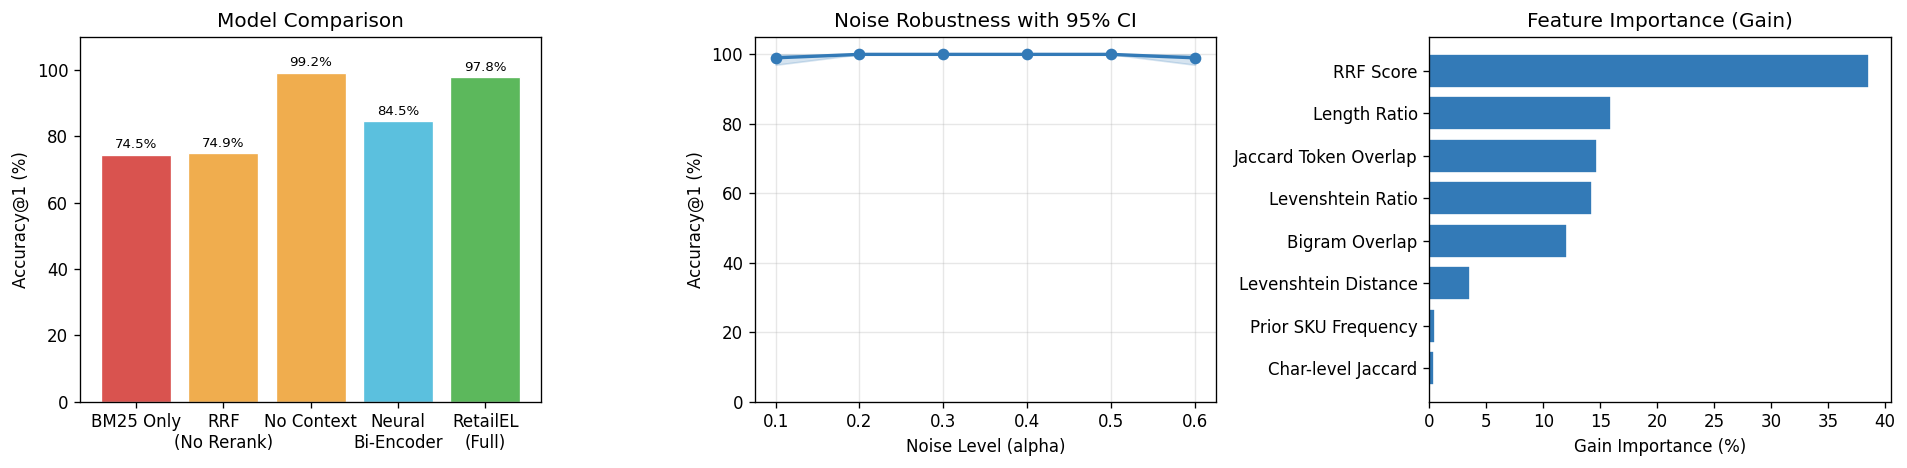

Saved -> results/figures.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Model comparison bar chart
models = ["BM25 Only","RRF\n(No Rerank)","No Context","Neural\nBi-Encoder","RetailEL\n(Full)"]
accs   = [acc_bm25*100, acc_norr*100, acc_noctx*100, acc_neural*100, acc1*100]
colors = ["#d9534f","#f0ad4e","#f0ad4e","#5bc0de","#5cb85c"]
bars   = axes[0].bar(models, accs, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Accuracy@1 (%)")
axes[0].set_title("Model Comparison")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)

# Plot 2: Noise robustness
alphas = [float(k) for k in noise_results]
naccs  = [noise_results[k]["acc"]*100 for k in noise_results]
lo_ci  = [noise_results[k]["ci_lo"]*100 for k in noise_results]
hi_ci  = [noise_results[k]["ci_hi"]*100 for k in noise_results]
axes[1].plot(alphas, naccs, 'o-', color='#337ab7', linewidth=2)
axes[1].fill_between(alphas, lo_ci, hi_ci, alpha=0.2, color='#337ab7')
axes[1].set_xlabel("Noise Level (alpha)")
axes[1].set_ylabel("Accuracy@1 (%)")
axes[1].set_title("Noise Robustness with 95% CI")
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature importance
feat_gain  = full_m.feature_importance("gain")
tg_total   = feat_gain.sum()+1e-9
feat_pcts  = [g/tg_total*100 for g in feat_gain]
sorted_idx = np.argsort(feat_pcts)
axes[2].barh([FEATURE_NAMES[i] for i in sorted_idx],
             [feat_pcts[i] for i in sorted_idx],
             color='#337ab7', edgecolor='white')
axes[2].set_xlabel("Gain Importance (%)")
axes[2].set_title("Feature Importance (Gain)")

plt.tight_layout()
plt.savefig("results/figures.png", bbox_inches='tight')
plt.show()
print("Saved -> results/figures.png")

## Section 16 — Save All Results to JSON

In [25]:
metrics = {
    "mode": "real",
    "main_results": {
        "full_pipeline_acc1":    round(acc1,    4),
        "no_basket_ctx_acc1":    round(acc_noctx,4),
        "bm25_only_acc1":        round(acc_bm25, 4),
        "no_reranker_acc1":      round(acc_norr, 4),
        "neural_biencoder_acc1": round(acc_neural,4),
    },
    "improvement_over_baselines_pp": {
        "vs_neural": round((acc1-acc_neural)*100, 2),
        "vs_bm25":   round((acc1-acc_bm25)*100,   2),
        "vs_norr":   round((acc1-acc_norr)*100,    2),
    },
    "performance": {
        "throughput_items_per_sec": round(throughput, 2),
        "wall_clock_ms":            round(wall_ms,    3),
        "stage_sum_ms":             round(stage_sum,  3),
        "overhead_ms":              round(overhead,   3),
        "llm_bypass_rate":          round(llm_bypass/len(test_items), 4),
        "stage_latency_ms": {
            s: {"mean": round(float(np.mean(v)),3),
                "p95":  round(float(np.percentile(v,95)),3)}
            for s,v in stage_lat.items()
        },
    },
    "noise_robustness": {
        "pos_variant_acc":  round(acc_var, 4),
        "canonical_acc":    round(acc_can, 4),
        "synthetic_sweep":  noise_results,
    },
    "category_accuracy": category_acc,
    "feature_ablation": {
        "full_model_acc": round(full_acc, 4),
        "leave_one_out":  loo_results,
        "gain_importance":{
            name: round(float(g/tg_total*100),2)
            for name,g in zip(FEATURE_NAMES, feat_gain)
        },
    },
    "dataset_stats": {
        "train_items": len(train_items),
        "val_items":   len(val_items),
        "test_items":  len(test_items),
        "num_skus":    len(pipeline.catalogue),
    }
}

Path("results/metrics_real.json").write_text(json.dumps(metrics, indent=2))
print("All results saved -> results/metrics_real.json")

# Download results
from google.colab import files
files.download("results/metrics_real.json")
files.download("results/figures.png")
print("Downloads started.")

All results saved -> results/metrics_real.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.
